# Preview Data
Load a few images, form a few interferograms and phase triplets

In [5]:
import glob
import rasterio
from scipy.ndimage import uniform_filter
from scipy.stats import pearsonr
import os
import numpy as np
from matplotlib import pyplot as plt

## Interferograms (HH and HV)

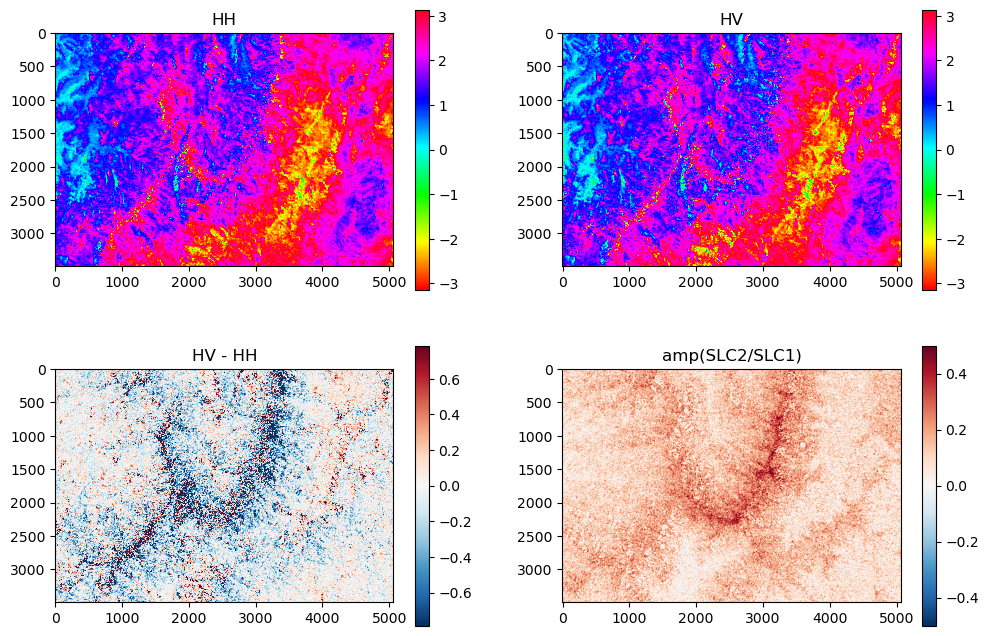

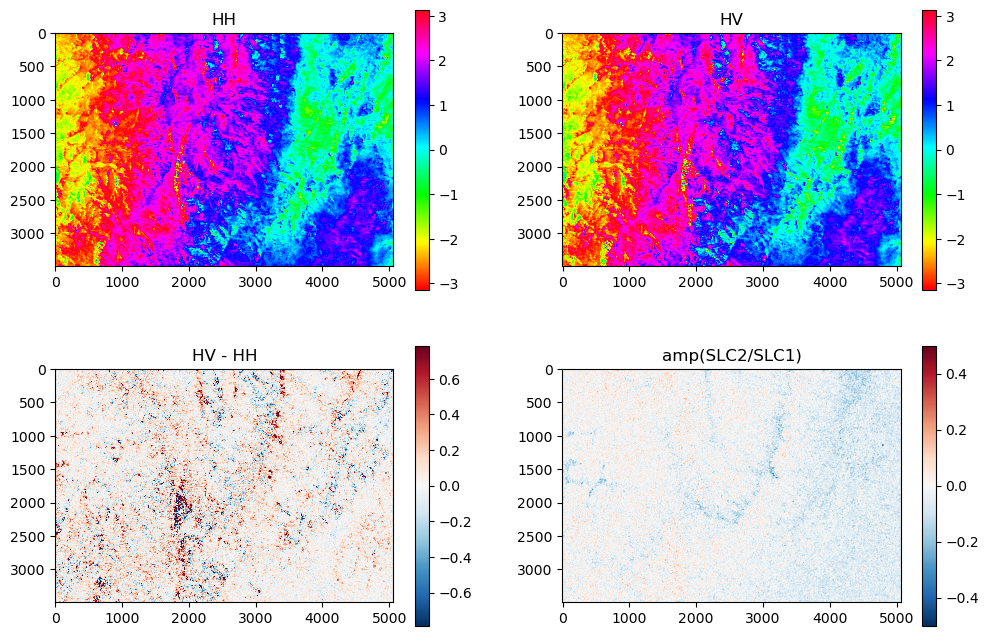

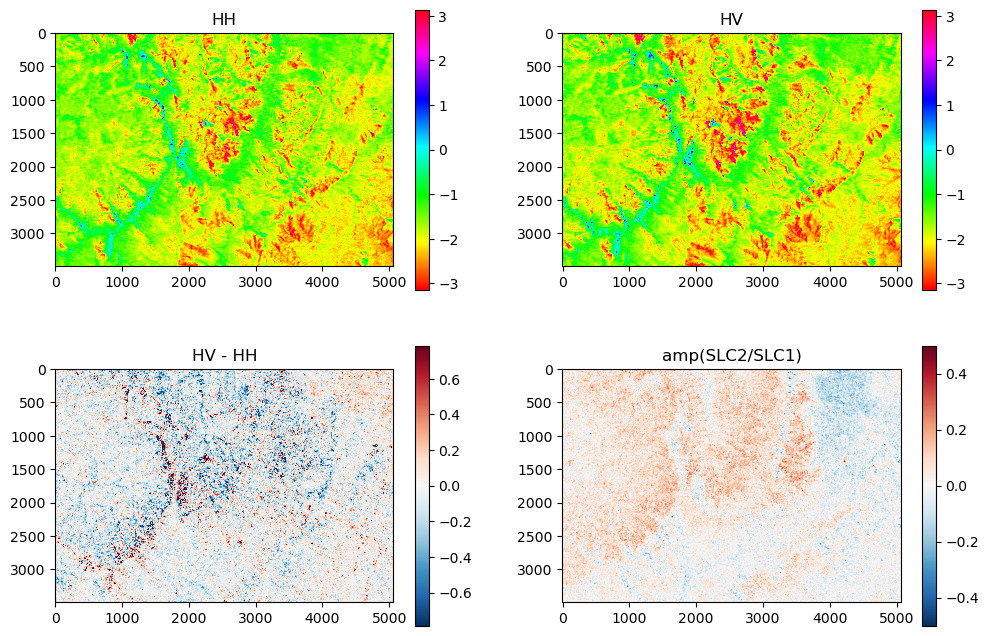

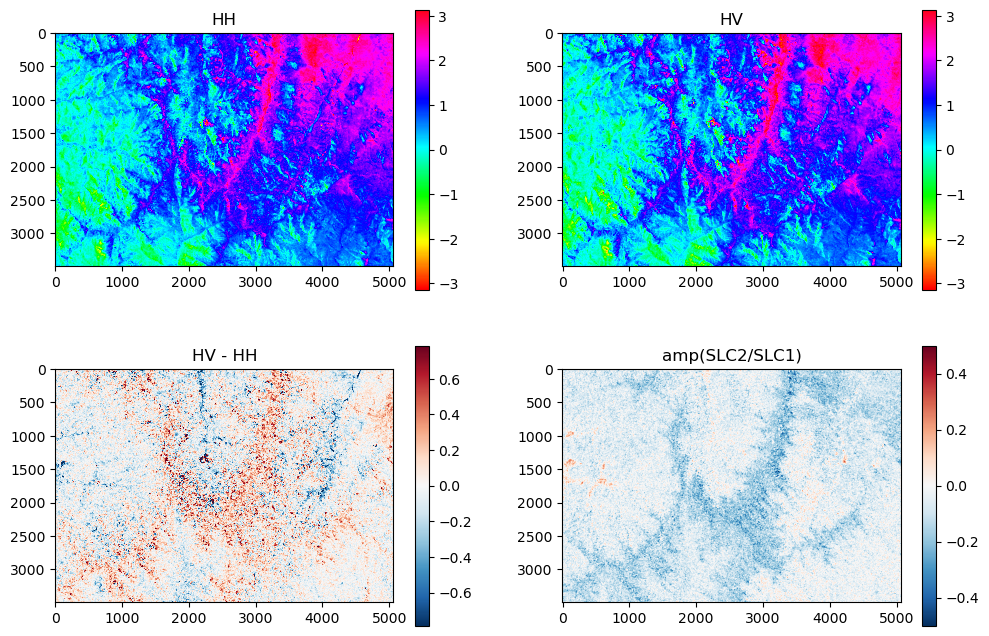

In [4]:
download_folder = '/data2/rb894/SAR/NISAR/nc_test'
gslc_paths_HH = sorted(glob.glob(os.path.join(download_folder, 'HH', './*.tif')))
gslc_paths_HV = sorted(glob.glob(os.path.join(download_folder, 'HV', './*.tif')))


pairs = [[1, 2], [2, 3], [1, 4], [3, 4]]

for pair in pairs:
    slc1 = rasterio.open(gslc_paths_HH[pair[0]]).read(1)#[1000:2000, 1000:3000]
    slc2 = rasterio.open(gslc_paths_HH[pair[1]]).read(1)#[1000:2000, 1000:3000]
    infgm_HH = uniform_filter(slc2 * slc1.conj(), size=(20, 20))

    amp_ratio = uniform_filter(np.log10(np.abs(slc2)**2 / np.abs(slc1)**2), size=(20, 20))

    slc1 = rasterio.open(gslc_paths_HV[pair[0]]).read(1)#[1000:2000, 1000:3000]
    slc2 = rasterio.open(gslc_paths_HV[pair[1]]).read(1)#[1000:2000, 1000:3000]
    infgm_HV = uniform_filter(slc2 * slc1.conj(), size=(20, 20))

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    im = ax[0, 0].imshow(np.angle(infgm_HH), vmin=-np.pi, vmax=np.pi, cmap='hsv', interpolation='none')
    plt.colorbar(im, ax=ax[0, 0])
    ax[0, 0].set_title('HH')

    im = ax[0, 1].imshow(np.angle(infgm_HV), vmin=-np.pi, vmax=np.pi, cmap='hsv', interpolation='none')
    plt.colorbar(im, ax=ax[0, 1])
    ax[0, 1].set_title('HV')
    

    im = ax[1, 0].imshow(np.angle(infgm_HV * infgm_HH.conj()), vmin=-np.pi/4, vmax=np.pi/4, cmap='RdBu_r', interpolation='none')
    plt.colorbar(im, ax=ax[1, 0])
    ax[1, 0].set_title('HV - HH')

    im = ax[1, 1].imshow(amp_ratio, vmin=-0.5, vmax=0.5, cmap='RdBu_r', interpolation='none')
    plt.colorbar(im, ax=ax[1, 1])
    ax[1, 1].set_title('amp(SLC2/SLC1)')


    plt.show()

PearsonRResult(statistic=-0.24275784, pvalue=0.0)


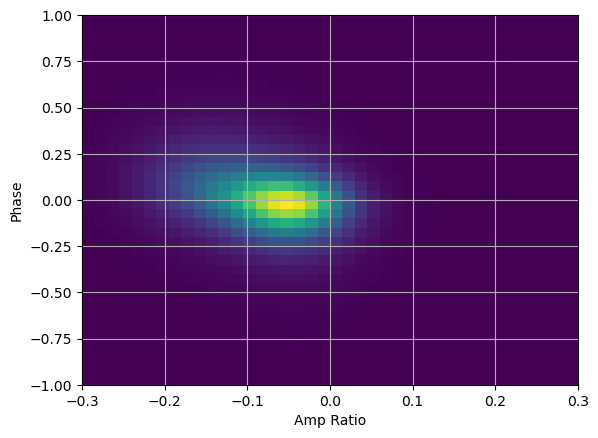

In [6]:
r = pearsonr(amp_ratio.flatten(), np.angle(infgm_HV * infgm_HH.conj()).flatten())
print(r)
plt.hist2d(amp_ratio.flatten(), np.angle(infgm_HV * infgm_HH.conj()).flatten(), bins=40, range=[[-0.3, 0.3], [-1, 1]])
plt.xlabel('Amp Ratio')
plt.ylabel('Phase')
plt.grid()
plt.show()

## Phase Triplets

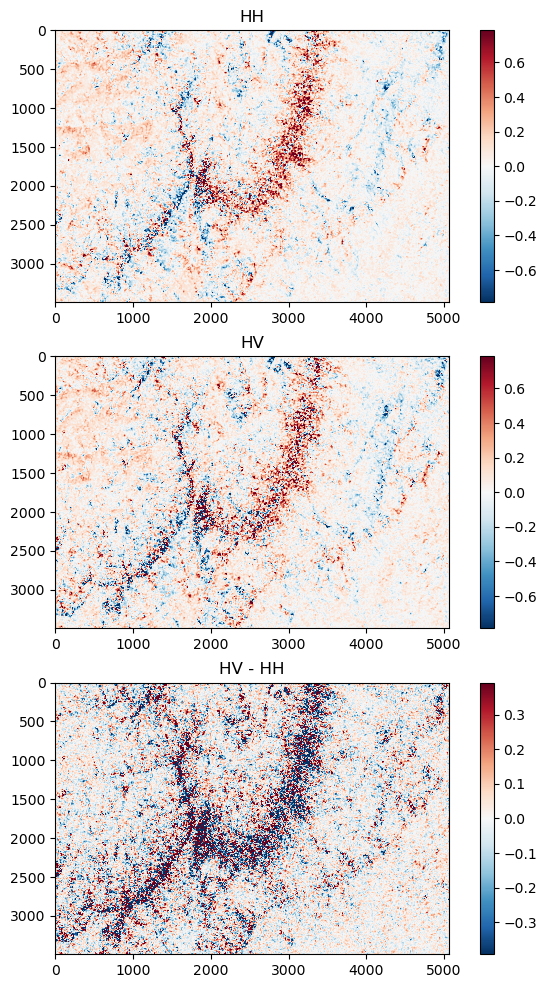

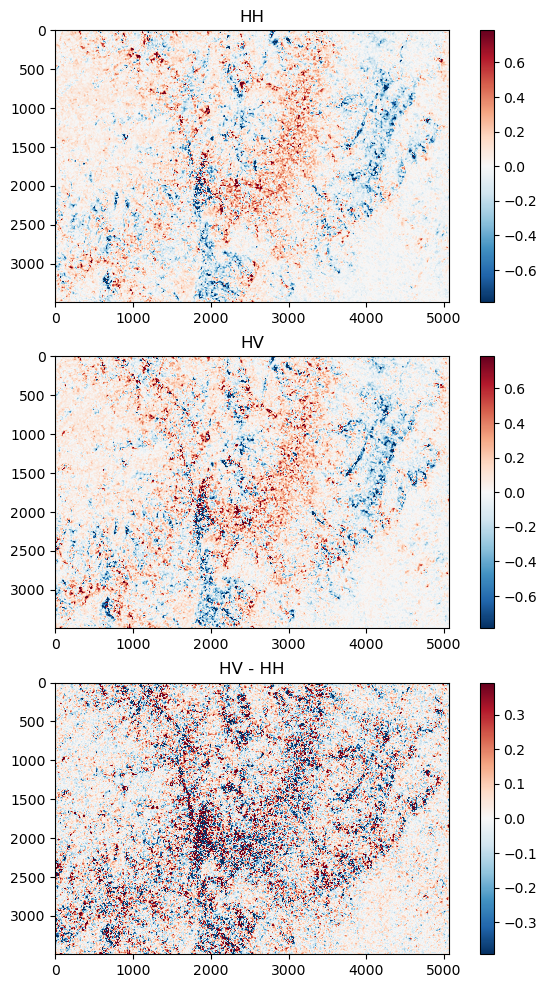

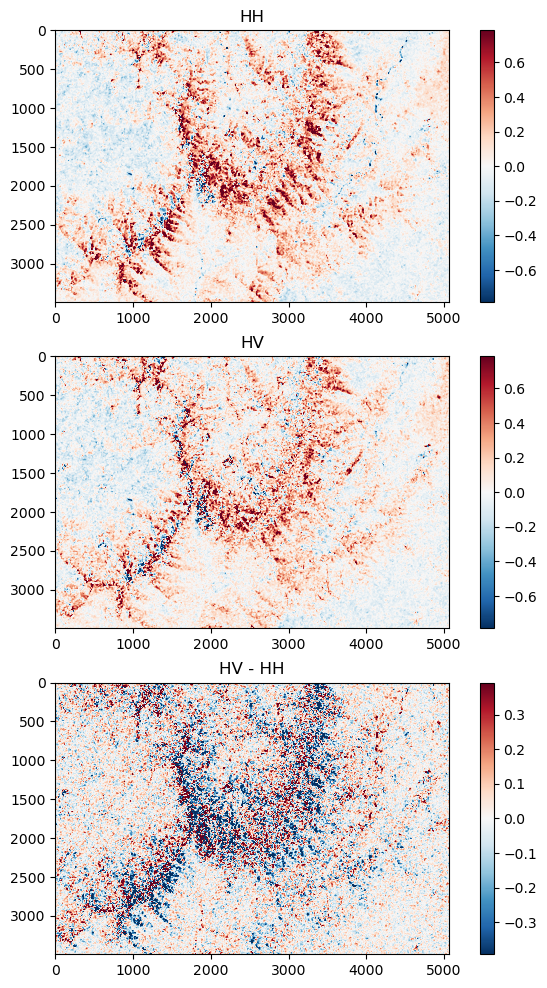

In [7]:
triplets = [[1, 2, 3], [2, 3, 4], [1, 3, 4]]

for tr in triplets:
    slc1 = rasterio.open(gslc_paths_HH[tr[0]]).read(1)
    slc2 = rasterio.open(gslc_paths_HH[tr[1]]).read(1)
    slc3 = rasterio.open(gslc_paths_HH[tr[2]]).read(1)

    infgm_HH_1 = uniform_filter(slc2 * slc1.conj(), size=(20, 20))
    infgm_HH_2 = uniform_filter(slc3 * slc2.conj(), size=(20, 20))
    infgm_HH_3 = uniform_filter(slc3 * slc1.conj(), size=(20, 20))
    triplet_HH = uniform_filter(infgm_HH_1 * infgm_HH_2 * infgm_HH_3.conj(), size=(10, 10))

    slc1 = rasterio.open(gslc_paths_HV[tr[0]]).read(1)
    slc2 = rasterio.open(gslc_paths_HV[tr[1]]).read(1)
    slc3 = rasterio.open(gslc_paths_HV[tr[2]]).read(1)

    infgm_HV_1 = uniform_filter(slc2 * slc1.conj(), size=(20, 20))
    infgm_HV_2 = uniform_filter(slc3 * slc2.conj(), size=(20, 20))
    infgm_HV_3 = uniform_filter(slc3 * slc1.conj(), size=(20, 20))
    triplet_HV = uniform_filter(infgm_HV_1 * infgm_HV_2 * infgm_HV_3.conj(), size=(10, 10))
    
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8, 12))
    im = ax[0].imshow(np.angle(triplet_HH), vmin=-np.pi/4, vmax=np.pi/4, interpolation='none', cmap='RdBu_r')
    plt.colorbar(im, ax=ax[0])
    ax[0].set_title('HH')
    im = ax[1].imshow(np.angle(triplet_HV), vmin=-np.pi/4, vmax=np.pi/4, interpolation='none', cmap='RdBu_r')
    ax[1].set_title('HV')
    plt.colorbar(im, ax=ax[1])
    im = ax[2].imshow(np.angle(triplet_HV * triplet_HH.conj()), vmin=-np.pi/8, vmax=np.pi/8, interpolation='none', cmap='RdBu_r')
    ax[2].set_title('HV - HH')
    plt.colorbar(im, ax=ax[2])

    plt.show()
